# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

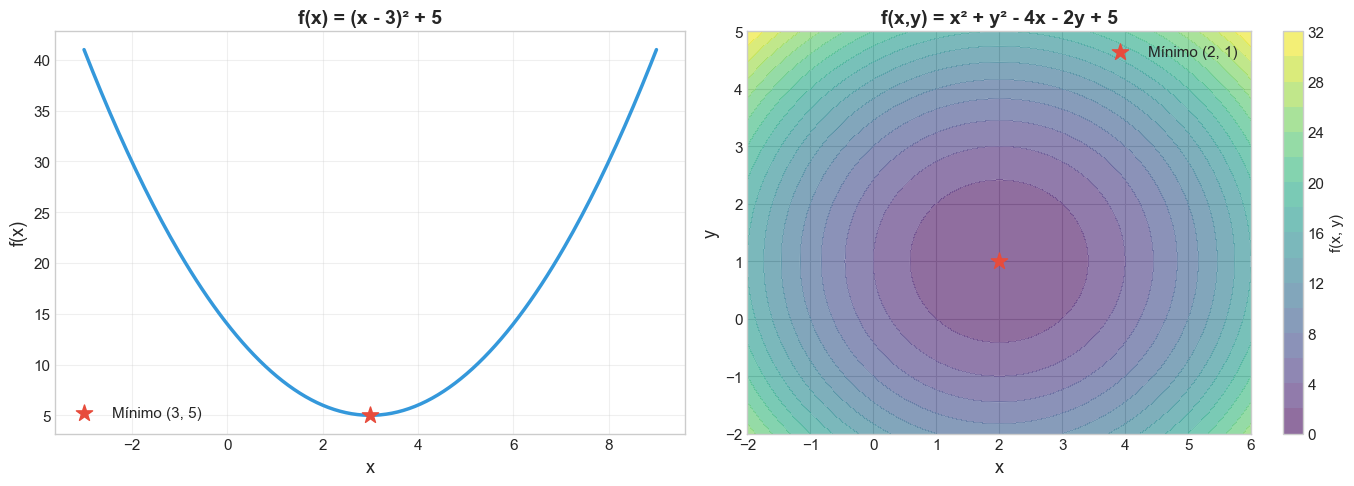

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [3]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa las variables:
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False
    
    # 2. Loop principal (max_iter iteraciones):
    for i in range(max_iter):
    #    a. Calcula el gradiente: g = df_1d(x_actual)
        g = df_1d(x_actual)
    #    b. Actualiza: x_nuevo = x_actual - learning_rate * g
        x_nuevo = x_actual - learning_rate * g
    #    c. Guarda en historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
    #    d. Verifica convergencia: si |x_nuevo - x_actual| < tolerancia -> convergido
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            break
    #    e. Actualiza x_actual = x_nuevo
        x_actual = x_nuevo
    # 3. Retorna el diccionario con resultados
    
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }


### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [4]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999995  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000005)


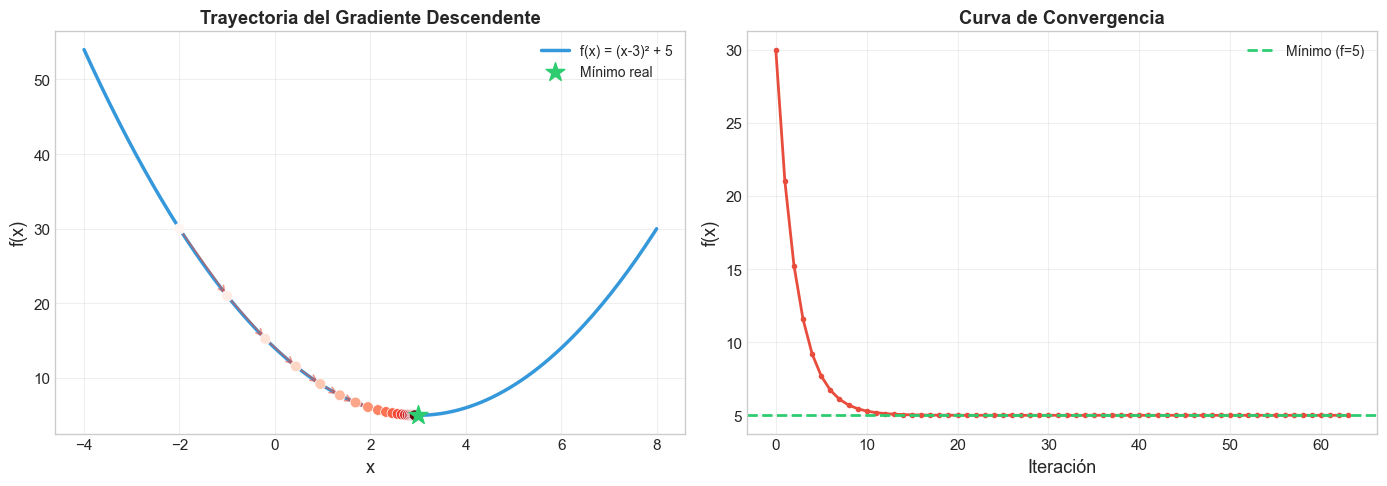

In [5]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [6]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr
for lr in learning_rates_prueba:
    resultados = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(resultados)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999995     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     2.999999     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

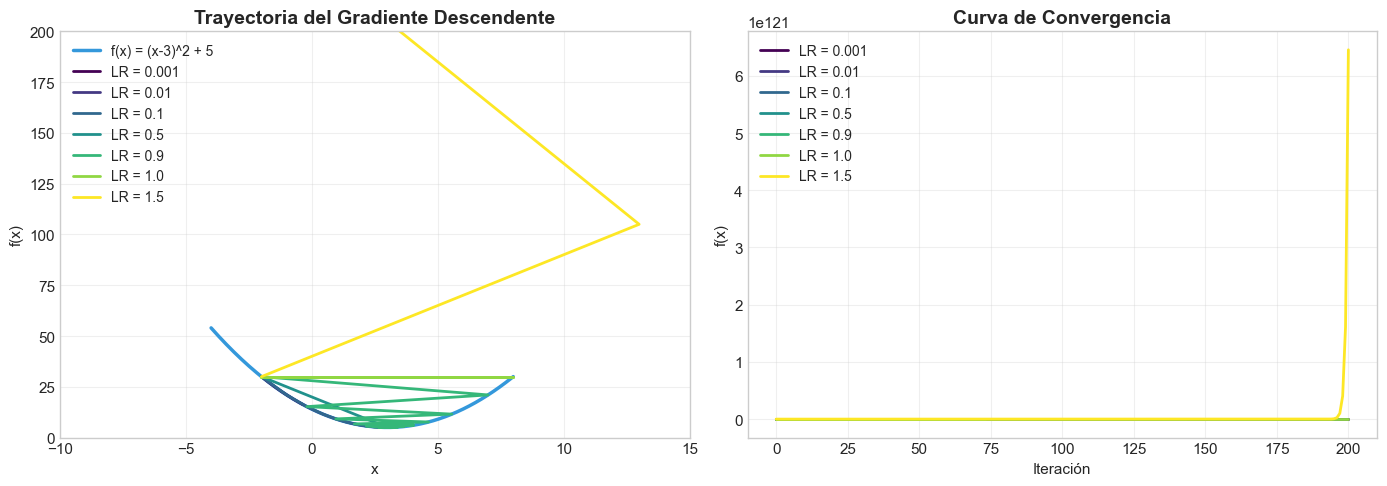

In [7]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

# Crea dos graficas:
# 1. Trayectoria sobre f(x) para cada LR (con diferentes colores)
# 2. Curva de convergencia f(x) vs iteracion para cada LR

# Pista: usa fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pista: usa colores distintos para cada LR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt_colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates_prueba)))
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)^2 + 5')

plt_titles = ['Trayectoria del Gradiente Descendente', 'Curva de Convergencia']
for ax, title in zip(axes, plt_titles):
    ax.set_title(title, fontweight='bold', fontsize=14)
for i, (lr, res) in enumerate(zip(learning_rates_prueba, resultados_lr)):
    axes[0].plot(res['historial_x'], res['historial_f'], color=plt_colors[i], linewidth=2, label=f"LR = {lr}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_xlim(-10, 15)   
axes[0].set_ylim(0, 200)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, (lr, res) in enumerate(zip(learning_rates_prueba, resultados_lr)):
    axes[1].plot(range(len(res['historial_f'])), res['historial_f'], color=plt_colors[i], linewidth=2, label=f"LR = {lr}")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("f(x)")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Responde estas preguntas basandote en tus experimentos:**

1. **¿Qué pasa con un learning rate muy pequeño (0.001)?**
   - Converge, pero muy lentamente. Da pasos tan pequeños que necesita muchas iteraciones para llegar al mínimo. Con max_iter=200 se queda muy lejos del óptimo.

2. **¿Cuál consideras el mejor learning rate y por qué?**
   - LR = 0.5 llega al mínimo exacto (x=3, f(x)=5) en solo 2 iteraciones. Es el más eficiente por amplio margen. LR = 0.1 también converge bien pero necesita 63 iteraciones.

3. **¿Qué pasa con learning rates >= 1.0?**
   - Ambos fallan pero de formas distintas: LR = 1.0 no converge y LR = 1.5 diverge hasta valores muy grandes, confirmando que el umbral de estabilidad para esta función es estrictamente LR < 1.0.

4. **¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?**
   - Los datos lo confirman perfectamente: x_final = -2.0, que es exactamente el punto inicial. Con LR = 1.0 el algoritmo oscila durante las 200 iteraciones sin avanzar nunca. Nunca diverge pero tampoco converge — es el caso límite exacto.

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [8]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa:
    #    - x_actual, y_actual = x_inicial, y_inicial
    #    - historiales vacios
    x_actual, y_actual = x_inicial, y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False

    # 2. Loop principal:
    for i in range(max_iter):
        #    a. Calcula gradiente: g = grad_2d(x_actual, y_actual)  -> [gx, gy]
        g = grad_2d(x_actual, y_actual)

        #    b. Actualiza ambos parametros:
        #       x_nuevo = x_actual - lr * g[0]
        #       y_nuevo = y_actual - lr * g[1]
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]

        # Detener si diverge
        if not np.isfinite(x_nuevo) or not np.isfinite(y_nuevo) or abs(x_nuevo) > 1e10:
            break

        #    c. Guarda en historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))

        #    d. Verifica convergencia: si ||gradiente|| < tolerancia -> convergido
        #       (norma del gradiente: np.linalg.norm(g))
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            break

        #    e. Actualiza x_actual, y_actual
        x_actual, y_actual = x_nuevo, y_nuevo

    # 3. Retorna diccionario con resultados
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [9]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


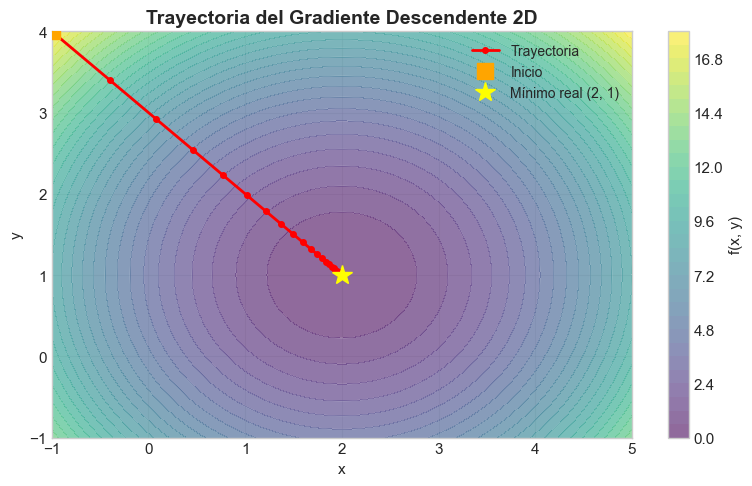

In [10]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria

fig, ax = plt.subplots(figsize=(8, 5))

# 1. Mapa de contornos de f(x, y)
x_range = np.linspace(-1, 5, 200)
y_range = np.linspace(-1, 4, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = f_2d(X, Y)

contourf = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
contour  = ax.contour(X, Y, Z, levels=30, colors='white', linewidths=0.5, alpha=0.3)
plt.colorbar(contourf, ax=ax, label='f(x, y)')

# 2. Trayectoria del gradiente descendente
ax.plot(resultado_2d['historial_x'], resultado_2d['historial_y'],
        'o-', color='red', linewidth=2, markersize=4, label='Trayectoria')

# 3. Punto de inicio
ax.plot(resultado_2d['historial_x'][0], resultado_2d['historial_y'][0],
        's', color='orange', markersize=12, zorder=5, label='Inicio')

# 4. Minimo real en (2, 1)
ax.plot(2, 1, '*', color='yellow', markersize=15, zorder=5, label='Mínimo real (2, 1)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Trayectoria del Gradiente Descendente 2D', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados

resultados_2d = []
for (xi, yi) in puntos_iniciales:
    res = gradiente_descendente_2d(x_inicial=xi, y_inicial=yi, learning_rate=0.1)
    resultados_2d.append(res)

# Tabla de resultados
print("EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES")
print("=" * 70)
print(f"{'Inicio':>14} {'x_final':>10} {'y_final':>10} {'f(x,y)':>10} {'Iters':>8} {'Convergió':>10}")
print("-" * 70)
for (xi, yi), res in zip(puntos_iniciales, resultados_2d):
    print(f"({xi:>4}, {yi:>4})   {res['x_final']:>10.6f} {res['y_final']:>10.6f} "
          f"{res['f_final']:>10.6f} {res['iteraciones']:>8} {str(res['convergido']):>10}")

EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES
        Inicio    x_final    y_final     f(x,y)    Iters  Convergió
----------------------------------------------------------------------
(-1.0,  4.0)     2.000000   1.000000   0.000000       73       True
( 5.0, -1.0)     2.000000   1.000000   0.000000       72       True
( 0.0,  0.0)     2.000000   1.000000   0.000000       70       True


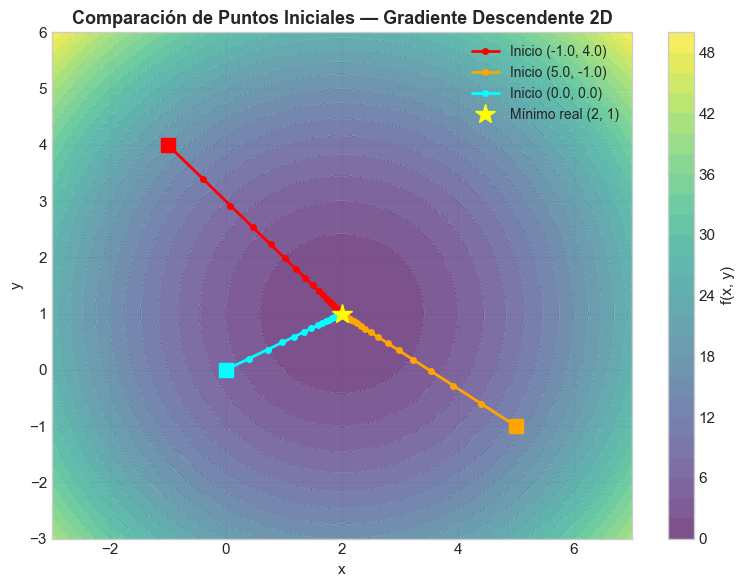

In [12]:
# Visualizacion comparativa
fig, ax = plt.subplots(figsize=(8, 6))

x_range = np.linspace(-3, 7, 200)
y_range = np.linspace(-3, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = f_2d(X, Y)

contourf = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.contour(X, Y, Z, levels=30, colors='white', linewidths=0.5, alpha=0.4)
plt.colorbar(contourf, ax=ax, label='f(x, y)')

# Trayectoria y punto inicial de cada experimento
colors = ['red', 'orange', 'cyan']
for (xi, yi), res, color in zip(puntos_iniciales, resultados_2d, colors):
    ax.plot(res['historial_x'], res['historial_y'],
            'o-', color=color, linewidth=2, markersize=4, label=f'Inicio ({xi}, {yi})')
    ax.plot(xi, yi, 's', color=color, markersize=10, zorder=5)

# Minimo real
ax.plot(2, 1, '*', color='yellow', markersize=15, zorder=6, label='Mínimo real (2, 1)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Comparación de Puntos Iniciales — Gradiente Descendente 2D', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [13]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

# 1. Ejecuta TODOS los experimentos:
#    - 1D: learning_rates [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
#           desde x=-2.0
#    - 2D: learning_rates [0.001, 0.01, 0.1, 0.5]
#           desde (-1, 4), (5, -1), (0, 0)

learning_rates_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_iniciales  = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

filas = []

# --- Experimentos 1D ---
for lr in learning_rates_1d:
    res = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr,
        'dimension':     '1D',
        'x_inicial':     -2.0,
        'y_inicial':     np.nan,
        'x_final':       res['x_final'],
        'y_final':       np.nan,
        'valor_minimo':  res['f_final'],
        'iteraciones':   res['iteraciones'],
        'convergido':    res['convergido'],
    })

# --- Experimentos 2D ---
for lr in learning_rates_2d:
    for (xi, yi) in puntos_iniciales:
        res = gradiente_descendente_2d(x_inicial=xi, y_inicial=yi, learning_rate=lr, max_iter=200)
        filas.append({
            'learning_rate': lr,
            'dimension':     '2D',
            'x_inicial':     xi,
            'y_inicial':     yi,
            'x_final':       res['x_final'],
            'y_final':       res['y_final'],
            'valor_minimo':  res['f_final'],
            'iteraciones':   res['iteraciones'],
            'convergido':    res['convergido'],
        })

# 2. Crea el DataFrame
df_experimentos = pd.DataFrame(filas)

# 3. Guardalo como CSV
df_experimentos.to_csv('experimentos_gd.csv', index=False)

In [14]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999995e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  2.999999e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -1.015484e-02  3.010155  8.081445e+00  

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **¿Cuál es el rango de learning rates que funciona bien para estas funciones?**
   - Para estas funciones el rango efectivo es 0.1 a 0.5. Con LR=0.1 converge en 70 iteraciones en promedio y con LR=0.5 en solo 2. Por debajo de 0.1 es demasiado lento y por encima de 1.0 diverge u oscila.

2. **¿El punto inicial afecta si el algoritmo converge? \u00bfAfecta cu\u00e1ntas iteraciones necesita?**
   - Para estas funciones no afecta la convergencia puesto que ambas funciones son convexas y tienen un único mínimo global. Sí afecta cuántas iteraciones necesita: un punto más lejano al mínimo requiere más pasos.

3. **¿Qué pasaría si la función tuviera múltiples mínimos locales? (piensa en una función como `sin(x) + x\u00b2/10`)**
   - Aquí sí va a importar el valor del punto inicial, con esta función, el gradiente descendente quedaría atrapado en el mínimo local más cercano al punto inicial, no necesariamente el mínimo global

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la función de costo es como `f(x,y)`. ¿Por qué es importante elegir bien el learning rate al entrenar?**
   - Los pesos del modelo son miles de variables como x y y, y la función de costo mide qué tan mal predice el modelo. Un LR muy pequeño convierte el entrenamiento más lento. Un LR muy grande hace que los pesos diverjan y el modelo nunca aprenda. Elegir bien el LR es la diferencia entre un modelo que converge en horas versus uno que nunca converge.

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - El gradiente te dice exactamente en qué dirección decrece más rápido la función, así que cada paso está garantizado ser útil. Probar valores al azar es ciego y en un espacio de miles de dimensiones sería computacionalmente imposible encontrar el mínimo así, mientras que el gradiente escala eficientemente sin importar cuántas dimensiones tenga el problema.

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [15]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relación real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w = 3 y b = 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w = 3 y b = 7 usando SGD


In [16]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa w = 0, b = 0
    w, b = 0, 0
    historial_loss = []
    historial_w    = []
    historial_b    = []

    # 2. Para cada epoch:
    for epoch in range(epochs):
        #    a. Mezcla los indices aleatoriamente
        indices = np.random.permutation(len(X))

        #    b. Para cada mini-batch:
        for inicio in range(0, len(X), batch_size):
            idx       = indices[inicio : inicio + batch_size]
            X_batch   = X[idx]
            y_batch   = y[idx]

            #       - Calcula prediccion: y_pred = w * X_batch + b
            y_pred = w * X_batch + b

            #       - Calcula error: error = y_batch - y_pred
            error = y_batch - y_pred

            #       - Calcula gradientes:
            #           dw = -2/batch_size * sum(error * X_batch)
            #           db = -2/batch_size * sum(error)
            dw = -2 / len(X_batch) * np.sum(error * X_batch)
            db = -2 / len(X_batch) * np.sum(error)

            #       - Actualiza: w = w - lr * dw, b = b - lr * db
            w -= learning_rate * dw
            b -= learning_rate * db

        #    c. Calcula MSE del epoch completo y guarda en historial
        y_pred_total = w * X + b
        mse          = np.mean((y - y_pred_total) ** 2)
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final':        w,
        'b_final':        b,
        'historial_loss': historial_loss,
        'historial_w':    historial_w,
        'historial_b':    historial_b,
    }

In [ ]:
# Ejecuta SGD y visualiza resultados

resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)
print("RESULTADOS SGD — REGRESIÓN LINEAL")
print("=" * 50)
print(f"{'Epoch':>8} {'w':>10} {'b':>10} {'MSE':>12}")
print("-" * 50)
for i, (w, b, loss) in enumerate(zip(resultado_sgd['historial_w'],
                                      resultado_sgd['historial_b'],
                                      resultado_sgd['historial_loss']), start=1):
    print(f"{i:>8} {w:>10.4f} {b:>10.4f} {loss:>12.4f}")

print("=" * 50)
print(f"{'w final':>8}: {resultado_sgd['w_final']:.4f}  (real: 3)")
print(f"{'b final':>8}: {resultado_sgd['b_final']:.4f}  (real: 7)")
print(f"{'MSE final':>8}: {resultado_sgd['historial_loss'][-1]:.4f}")

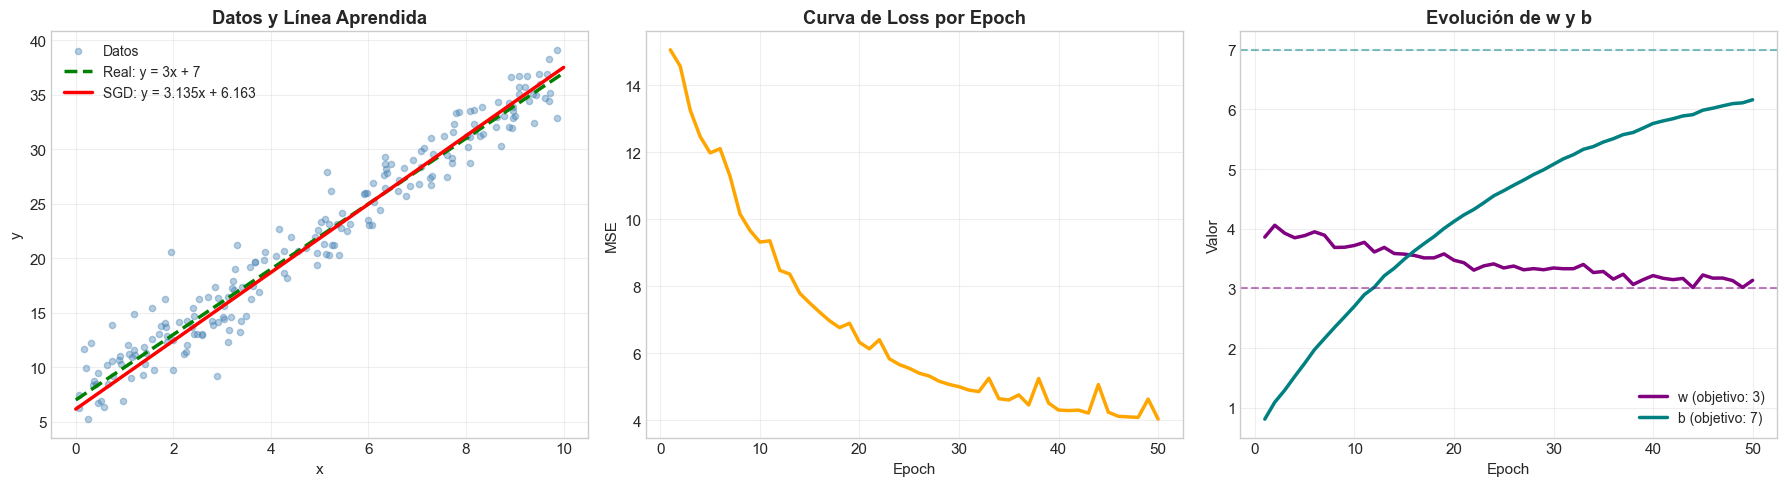


Resultados finales:
  w aprendido: 3.1347  (real: 3)
  b aprendido: 6.1625  (real: 7)
  Loss final:  4.0334


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfica 1: Datos + línea aprendida vs línea real ---
x_linea = np.linspace(0, 10, 100)
axes[0].scatter(X_sgd, y_sgd, alpha=0.4, color='steelblue', s=20, label='Datos')
axes[0].plot(x_linea, 3 * x_linea + 7,
             color='green', linewidth=2.5, linestyle='--', label='Real: y = 3x + 7')
axes[0].plot(x_linea, resultado_sgd['w_final'] * x_linea + resultado_sgd['b_final'],
             color='red', linewidth=2.5,
             label=f"SGD: y = {resultado_sgd['w_final']:.3f}x + {resultado_sgd['b_final']:.3f}")
axes[0].set_title('Datos y Línea Aprendida', fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Gráfica 2: Curva de loss por epoch ---
axes[1].plot(range(1, len(resultado_sgd['historial_loss']) + 1),
             resultado_sgd['historial_loss'],
             color='orange', linewidth=2.5)
axes[1].set_title('Curva de Loss por Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)

# --- Gráfica 3: Evolución de w y b por epoch ---
epochs_range = range(1, len(resultado_sgd['historial_w']) + 1)
axes[2].plot(epochs_range, resultado_sgd['historial_w'],
             color='purple', linewidth=2.5, label='w (objetivo: 3)')
axes[2].plot(epochs_range, resultado_sgd['historial_b'],
             color='teal',   linewidth=2.5, label='b (objetivo: 7)')
axes[2].axhline(y=3, color='purple', linewidth=1.5, linestyle='--', alpha=0.5)
axes[2].axhline(y=7, color='teal',   linewidth=1.5, linestyle='--', alpha=0.5)
axes[2].set_title('Evolución de w y b', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Valor')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResultados finales:")
print(f"  w aprendido: {resultado_sgd['w_final']:.4f}  (real: 3)")
print(f"  b aprendido: {resultado_sgd['b_final']:.4f}  (real: 7)")
print(f"  Loss final:  {resultado_sgd['historial_loss'][-1]:.4f}")

In [26]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes
batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

resultados_batch = []
for bs in batch_sizes:
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    resultados_batch.append(res)

tipos = ['SGD puro', 'Mini-batch', 'Mini-batch', 'Mini-batch', 'GD puro']

df_batch = pd.DataFrame([{
    'batch_size':  bs,
    'tipo':        tipo,
    'w_final':     res['w_final'],
    'b_final':     res['b_final'],
    'mse_final':   res['historial_loss'][-1],
    'mse_inicial': res['historial_loss'][0],
} for bs, tipo, res in zip(batch_sizes, tipos, resultados_batch)])

print("COMPARACIÓN GD vs SGD — DIFERENTES BATCH SIZES")
print("=" * 70)
print(df_batch.to_string(index=False))

COMPARACIÓN GD vs SGD — DIFERENTES BATCH SIZES
 batch_size       tipo  w_final  b_final  mse_final  mse_inicial
          1   SGD puro 2.413296 6.998130  15.416160     6.167059
          8 Mini-batch 2.919165 7.190307   3.884849    12.731521
         32 Mini-batch 3.198099 6.188465   4.130655    14.903970
         64 Mini-batch 3.370711 4.882740   5.236287    15.444415
        200    GD puro 3.755606 2.140950  10.668475    78.484453


**Preguntas Bonus:**

1. **¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - GD puro arranca con mse_inicial=78.48 pero termina lejos del objetivo (w=3.75, b=2.14), siendo el peor resultado con solo 50 epochs. SGD puro arranca con mse_inicial=6.16 y aunque su mse_final=15.4 parece alto, su w=2.41 ya está más cerca del real. GD puro necesitaría muchos más epochs para converger porque actualiza pesos solo una vez por epoch, mientras SGD actualiza 200 veces por epoch.

2. **¿Cuál batch_size te dio los mejores resultados? ¿Por qué?**
   - bs=8 con mse_final=3.88, w=2.91 y b=7.19 es el más cercano a los valores reales w=3, b=7.

3. **¿Por qué la curva de loss de SGD es más ruidosa que la de GD?**
   - Porque con bs=1 cada actualización usa una sola muestra, que puede ser atípica o ruidosa. El gradiente estimado varía mucho de muestra en muestra, haciendo que los pesos oscilen. GD puro usa todas las 200 muestras para calcular el gradiente, obteniendo una dirección más estable y suave en cada paso.

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_